# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
# Import models you're considering

import optuna
import torchmetrics
import copy

d:\MASTER\OpenCampus_Applied_MachineLearning\.OC_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Model Selection

[Discuss the type(s) of models you consider for this task, and justify the selection.]



## Feature Engineering

[Describe any additional feature engineering you've performed beyond what was done for the baseline model.]  
Feature engineering was done separately in the file [data_engineering_features.ipynb](hanabi_ml\data_engineering_features.ipynb). Below is an overview of the final dataset.


In [ ]:
# Load the dataset
# For feature engineering see the script "data_engineering_features.ipynb"
df = pd.read_csv("../hanabi_dataset_features.csv")

# Feature and target variable selection
X = df.iloc[:, 2:]
y = df['final_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

df.head()

,file_source,final_score,p1_green1,p1_green2,p1_green3,p1_green4,p1_green5,p1_yellow1,p1_yellow2,p1_yellow3,...,white_count,blue_count,red_count,p1_hand_sum,p1_avg_value,p2_hand_sum,p2_avg_value,p1_unique_cards,p2_unique_cards,avg_max_possible_progress
0,gamec4a276e8bbb31378.log,10,0,0,0,0,0,0,0,0,...,1,3,4,17,3.4,13,2.6,4,5,0.2
1,game146052cdf75868b1.log,21,0,0,0,0,0,0,0,0,...,2,3,4,15,3.0,10,2.0,5,5,1.2
2,gamea89f449023dbd46f.log,8,0,0,0,0,0,0,0,0,...,1,3,3,12,2.4,12,2.4,4,4,0.4
3,gamee78abd094f6f5d73.log,14,0,0,0,0,0,0,0,0,...,2,3,3,14,2.8,12,2.4,4,4,0.6
4,game53b40ed46697f583.log,6,0,0,0,0,0,0,0,0,...,2,2,4,13,2.6,13,2.6,5,5,1.4


## Hyperparameter Tuning

[Discuss any hyperparameter tuning methods you've applied, such as Grid Search or Random Search, and the rationale behind them.]

Hyperparameter tuning was performed using **Optuna** with the **Tree-structured Parzen Estimator (TPE)** sampler, a Bayesian optimization method. Unlike Grid Search, which evaluates every combination of predefined values, or Random Search, which samples configurations randomly, TPE uses the results of previous trials to guide the search toward more promising hyperparameter values. This makes the optimization more efficient, particularly when searching a large hyperparameter space.

The search space included both model architecture and training hyperparameters:
- **Number of hidden layers (2–4)** to control model depth.
- **Hidden layer size (32, 64, 128, 256)** to adjust model capacity.
- **Dropout rate (0.0–0.5)** to reduce overfitting.
- **Weight decay (1e-6–1e-2, log scale)** as L2 regularization.
- **Learning rate (1e-5–1e-2, log scale)** to control optimization.
- **Batch size (16, 32, 64, 128)** to influence training stability and efficiency.

A total of **500 trials** were performed using a fixed random seed (`seed=42`) to improve reproducibility. Each trial trained the neural network for 10 epochs and evaluated its performance on the validation set using **Mean Squared Error (MSE)**. The hyperparameter configuration with the lowest validation MSE was selected as the final model.


In [ ]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)

def define_search_space(trial):
    parameters = {}

    # Hyperparameter for model architecture
    # control the complexity and capacity of the neural network
    parameters["num_hidden_layers"] = trial.suggest_int(
        "num_hidden_layers",
        2,
        4
    )

    parameters["hidden_size"] = trial.suggest_categorical(
    "hidden_size",
    [32, 64, 128, 256]
    )

    # Hyperparameter for Regularization
    # help prevent overfitting
    parameters["dropout_rate"] = trial.suggest_float(
        "dropout_rate",
        0.0,
        0.5
    )

    parameters["weight_decay"] = trial.suggest_float(
        "weight_decay",
        1e-6,
        1e-2,
        log=True
    )

    # Hyperparameter for optimization
    # control how the network learns
    parameters["learning_rate"] = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    parameters["batch_size"] = trial.suggest_categorical(
        "batch_size",
        [16, 32, 64, 128]
    )

    return parameters

# Dynamic model definition
class HanabiDynamic(nn.Module):
    def __init__(
        self,
        input_dim,          # Number of input features
        num_hidden_layers,  # Number of hidden layers
        hidden_size,        # Neurons in each hidden layer
        dropout_rate        # Dropout probability
    ):
        super().__init__()

        layers = []

        current_dim = input_dim

        for _ in range(num_hidden_layers):

            layers.append(
                nn.Linear(current_dim, hidden_size)
            )

            layers.append(nn.ReLU())

            layers.append(
                nn.Dropout(dropout_rate)
            )

            current_dim = hidden_size

        layers.append(
            nn.Linear(current_dim, 1)
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Define the objective function for optuna
def objective(trial):

    params = define_search_space(trial)

    # Create model
    model = HanabiDynamic(
        input_dim=X_train.shape[1],
        num_hidden_layers=params["num_hidden_layers"],
        hidden_size=params["hidden_size"],
        dropout_rate=params["dropout_rate"]
    )

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"]
    )

    criterion = nn.MSELoss()

    # Create dataloaders
    X_train_tensor = torch.FloatTensor(X_train.values)
    y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

    X_val_tensor = torch.FloatTensor(X_val.values)
    y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1)

    train_dataset = torch.utils.data.TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True
    )

    # Training
    model.train()

    for epoch in range(10):

        for x_batch, y_batch in train_loader:

            optimizer.zero_grad()

            predictions = model(x_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            loss.backward()

            optimizer.step()

    # Validation
    model.eval()

    with torch.no_grad():

        val_predictions = model(X_val_tensor)

        val_loss = criterion(
            val_predictions,
            y_val_tensor
        )

    return val_loss.item()


In [ ]:
# Run optima on the defined search space. Set a seed.
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=500
)

print("The best model parameters:", study.best_params)
print("The best MSE:", study.best_value)
print("The best RMSE:", np.sqrt(study.best_value))

# assign the parameters to variables to use later on
num_hidden_layers = study.best_params["num_hidden_layers"]
hidden_size = study.best_params["hidden_size"]
dropout_rate = study.best_params["dropout_rate"]
learning_rate = study.best_params["learning_rate"]
weight_decay = study.best_params["weight_decay"]
batch_size = study.best_params["batch_size"]

[I 2026-06-22 00:10:52,429] A new study created in memory with name: no-name-e4e60314-bafb-4599-8d5d-6a7448966669
D:\Temp\ipykernel_12760\117557222.py:116: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
[I 2026-06-22 00:10:53,337] Trial 0 finished with value: 154.33250427246094 and parameters: {'num_hidden_layers': 3, 'hidden_size': 32, 'dropout_rate': 0.04403495045379535, 'weight_decay': 0.00563529181871338, 'learning_rate': 0.00010724218113483208, 'batch_size': 128}. Best is trial 0 with value: 154.3325042724609

The best model parameters: {'num_hidden_layers': 2, 'hidden_size': 128, 'dropout_rate': 0.16521747203591708, 'weight_decay': 1.2003252751022382e-06, 'learning_rate': 0.0003657794665487548, 'batch_size': 32}
The best MSE: 32.95446014404297
The best RMSE: 5.740597542420385


## Implementation

[Implement the final model(s) you've selected based on the above steps.]

The final model was implemented using the optimal hyperparameters identified during the Optuna hyperparameter tuning process. A dynamic feedforward neural network (`HanabiDynamic`) was constructed with the selected number of hidden layers, hidden layer size, and dropout rate. The model was trained using the Adam optimizer with the optimized learning rate and weight decay, while Mean Squared Error (MSE) was used as the loss function for this regression task.

Before training, all input features were normalized using a **Min-Max Scaler**. The scaler was fitted only on the training data and then applied to the validation and test sets to prevent data leakage. The scaled datasets were converted into PyTorch tensors and loaded into `DataLoader` objects to enable efficient mini-batch training.

The model was trained for a maximum of **100 epochs** using the optimized batch size. During each epoch, the model was first trained on the training set and then evaluated on the validation set. Training and validation losses were recorded to monitor the model's learning progress.

To improve generalization and training efficiency, two additional techniques were implemented:

- **Early stopping** was used with a patience of 10 epochs. If the validation loss did not improve for 10 consecutive epochs, training was terminated to reduce the risk of overfitting. The model parameters corresponding to the lowest validation loss were saved and restored after training.
- **ReduceLROnPlateau** was used as a learning rate scheduler. It monitored the validation loss and automatically reduced the learning rate by a factor of 0.5 after three consecutive epochs without improvement, allowing the optimizer to make smaller updates as training converged.

After training, the best-performing model (based on validation loss) was restored and evaluated on the unseen test dataset. Model performance was assessed using **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)**, providing the final evaluation of the neural network's predictive performance on unseen data.


In [5]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

#only transform the validation and test sets, no fitting -> avoiding data leakage
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [6]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [ ]:
#model = HanabiScorePredictor(input_dim= X_train.shape[1])
model = HanabiDynamic(
    input_dim=X_train.shape[1],
    num_hidden_layers=num_hidden_layers,
    hidden_size=hidden_size,
    dropout_rate=dropout_rate
)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

In [8]:
num_epochs = 100

train_losses = []
val_losses = []

# early stopping settings
patience = 10
best_val_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

# learning rate scheduler 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

for epoch in range(num_epochs):

    # Training
    model.train()
    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)
            val_loss = criterion(outputs, y_batch)

            running_val_loss += val_loss.item()

    epoch_val_loss = running_val_loss / len(val_loader)
    val_losses.append(epoch_val_loss)

    # LR scheduler
    scheduler.step(epoch_val_loss)

    # early stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0

        # save best model
        best_model_state = copy.deepcopy(model.state_dict())

    else:
        epochs_without_improvement += 1

    # Logging
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f} "
        f"Val Loss: {epoch_val_loss:.4f}"
    )

    # Stop training early
    if epochs_without_improvement >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore the best model
model.load_state_dict(best_model_state)

Epoch [1/100] Train Loss: 173.6912 Val Loss: 155.6318
Epoch [2/100] Train Loss: 121.9293 Val Loss: 70.3272
Epoch [3/100] Train Loss: 42.8294 Val Loss: 36.0407
Epoch [4/100] Train Loss: 34.1789 Val Loss: 34.6369
Epoch [5/100] Train Loss: 34.5324 Val Loss: 34.2552
Epoch [6/100] Train Loss: 33.7479 Val Loss: 33.9759
Epoch [7/100] Train Loss: 32.9580 Val Loss: 33.7777
Epoch [8/100] Train Loss: 32.1856 Val Loss: 33.5765
Epoch [9/100] Train Loss: 32.1295 Val Loss: 33.3645
Epoch [10/100] Train Loss: 32.4991 Val Loss: 33.2547
Epoch [11/100] Train Loss: 32.2354 Val Loss: 33.0442
Epoch [12/100] Train Loss: 31.8711 Val Loss: 33.5414
Epoch [13/100] Train Loss: 31.8862 Val Loss: 32.7653
Epoch [14/100] Train Loss: 31.7119 Val Loss: 33.0243
Epoch [15/100] Train Loss: 31.3017 Val Loss: 32.6474
Epoch [16/100] Train Loss: 30.9432 Val Loss: 32.5197
Epoch [17/100] Train Loss: 31.4063 Val Loss: 32.5801
Epoch [18/100] Train Loss: 31.0613 Val Loss: 32.6149
Epoch [19/100] Train Loss: 30.9720 Val Loss: 32.5377

<All keys matched successfully>

In [9]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)

    mse = nn.MSELoss()(predictions, y_test_tensor)
    rmse = torch.sqrt(mse)

print(f"Test MSE: {mse.item():.4f}")
print(f"Test RMSE: {rmse.item():.4f}")

Test MSE: 32.3247
Test RMSE: 5.6855


## Evaluation Metrics

[Clearly specify which metrics you'll use to evaluate the model performance, and why you've chosen these metrics.]


The primary evaluation metric is **Mean Squared Error** (MSE) which measures the average squared difference between predicted and actual scores. Lower MSE values indicate better model performance.

Additionally, we use **Root Mean Squared Error** (RMSE) to express prediction errors in the original score scale, making the results easier to interpret.

We also compute the **Mean Absolute Error** (MAE) which measures the average absolute prediction error and is less sensitive to large outliers than MSE.

Finally, the **R²** score is used to evaluate how well the model explains the variance in the target variable.

In [11]:
model.eval()

with torch.no_grad():
    predictions = model(X_test_tensor)

# Convert tensors to numpy arrays
y_true = y_test_tensor.numpy()
y_pred = predictions.numpy()

# Metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")

MSE: 32.3247
RMSE: 5.6855
MAE: 4.9420
R² Score: -0.0300


The regression model achieved an RMSE of 5.69 and an MAE of 4.94 on the unseen test dataset.

However, the R² score was slightly negative (-0.03), indicating that the model did not generalize well and performed worse than a simple baseline predictor using the average target value.

This suggests that the current feature representation may not sufficiently capture the factors influencing Hanabi scores or that the neural network architecture and hyperparameters require further optimization.

Possible improvements include additional feature engineering, hyperparameter tuning, normalization adjustments and increasing the amount of training data.

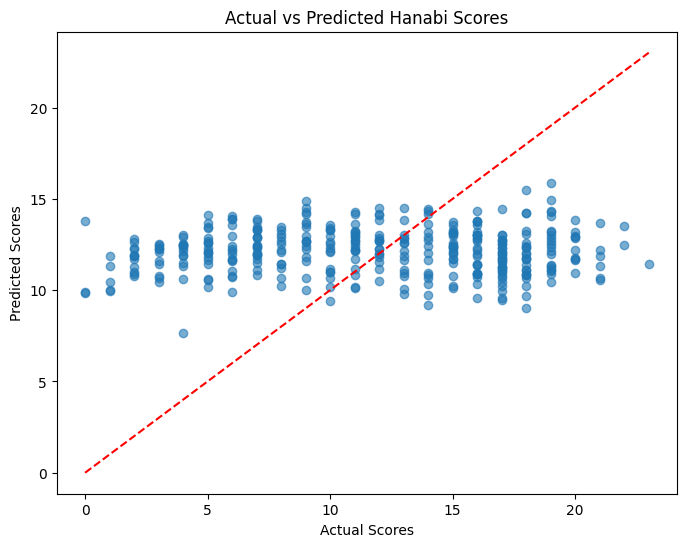

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.6)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Hanabi Scores")

# Ideal prediction line
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    'r--'
)

plt.show()

The scatter plot *comparing actual and predicted scores* shows that the model predictions are concentrated around the mean score range rather than following the ideal prediction line.

This indicates that the model tends to predict similar values for many samples and fails to accurately capture low and high score variations. Such behavior suggests underfitting, meaning that the model has not learned sufficiently strong relationships from the input features.

In [13]:
corr, _ = pearsonr(
    y_true.flatten(),
    y_pred.flatten()
)

print(f"Pearson Correlation: {corr:.4f}")

Pearson Correlation: 0.0493


The **Pearson correlation coefficient** between actual and predicted scores was close to zero (0.05), indicating only a negligible linear relationship between predictions and true values.

This result is consistent with the negative R² score and the scatter plot visualization, both of which suggest that the model failed to learn sufficiently informative patterns from the available feature set.

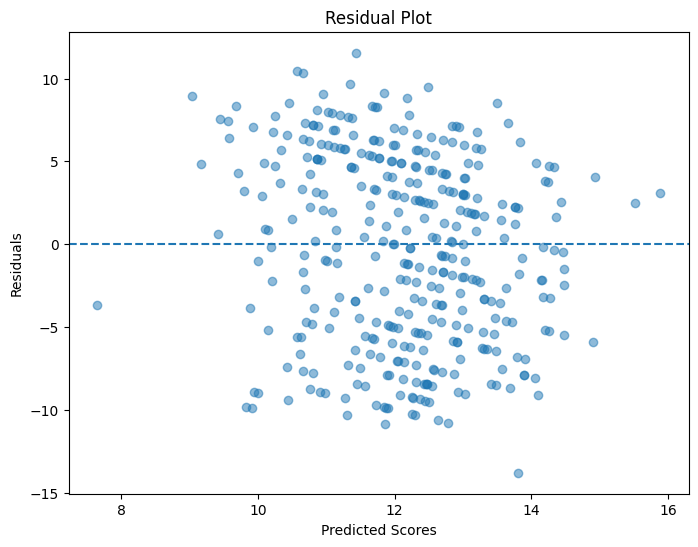

In [14]:
residuals = y_true.flatten() - y_pred.flatten()

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, linestyle='--')

plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

To visually evaluate the model's performance, a residual plot was generated, mapping the predicted Hanabi scores against their respective **prediction errors (residuals)**. In an ideal scenario, the residuals would form a random, unstructured cloud around the horizontal centerline ($y = 0$). However, our plot displays a *distinct downward diagonal trend* with visible striped patterns. Looking at the X-axis, the model's predictions are artificially compressed into a narrow band between roughly **8** and **15.5**, failing to capture the full 0-25 range of actual Hanabi scores. Because the model never predicts very low or very high scores, it consistently overestimates poor games (resulting in negative residuals on the left) and underestimates excellent games (resulting in positive residuals on the right). This systematic bias is a clear sign of underfitting, indicating that the model needs more training or a more complex architecture to predict the true extremes of the game.

## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [15]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
